#1. Importação do Dataset
Nesta etapa foi realizada a importação do conjunto de dados que será utilizado no desenvolvimento dos modelos preditivos de churn. O dataset foi carregado diretamente de um repositório no GitHub utilizando a biblioteca pandas, amplamente utilizada em Python para manipulação e análise de dados. Os dados utilizados já haviam sido previamente tratados em um projeto anterior, no qual foram realizadas etapas de limpeza, transformação e preparação das variáveis.

In [47]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/RaySilvaP/TelecomX-2/refs/heads/main/TelecomX_2_Data_.csv')

##**1.1. Colunas Irrelevantes**
Após a importação do arquivo, algumas colunas foram removidas do dataframe por não contribuírem para o objetivo da análise ou por representarem informações redundantes. A remoção dessas variáveis ajuda a evitar ruído no treinamento dos modelos e mantém apenas informações relevantes para a previsão de churn.

As colunas removidas foram:

* **customerID**
É apenas um identificador único de cada cliente. Como não possui relação com o comportamento de churn, não apresenta valor preditivo para os modelos.

* **Contas_Diarias**
Essa variável é uma derivação direta da coluna Charges.Monthly, representando essencialmente a mesma informação. Por ser redundante, foi removida para evitar duplicação de dados no modelo.

* **gender**
Foi considerada irrelevante para o treinamento dos modelos de churn neste contexto, não contribuindo de forma significativa para a previsão do cancelamento de serviços.

In [48]:
df.drop(['customerID', 'Contas_Diarias', 'gender'], axis=1, inplace=True)

##**1.2. Conversão de Variáveis Binárias**
Após a importação e limpeza inicial dos dados, foi realizada a conversão de algumas variáveis categóricas que possuíam valores "Yes" e "No" para valores numéricos 1 e 0. Essa etapa é importante porque a maioria dos algoritmos de machine learning trabalha melhor com dados numéricos, facilitando o treinamento e o processamento das informações pelos modelos.

Nesse caso, o valor 1 representa "Yes" (Sim) e o valor 0 representa "No" (Não). Essa transformação permite que os modelos interpretem essas variáveis de forma mais eficiente durante o processo de aprendizado.

In [49]:
colunas_converter = [
    'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'Churn']

df[colunas_converter] = df[colunas_converter].apply(
    lambda col: col.map({'Yes': 1, 'No': 0})
)

##**1.3. Codificação de Variáveis Categóricas (One-Hot Encoding)**
Após a conversão das variáveis binárias, a próxima etapa foi transformar algumas variáveis categóricas em variáveis numéricas utilizando a técnica de One-Hot Encoding. Esse procedimento é necessário porque muitos algoritmos de machine learning não conseguem interpretar diretamente valores categóricos em formato de texto.

O One-Hot Encoding funciona criando novas colunas binárias para cada categoria existente na variável original. Em cada linha, apenas a coluna correspondente à categoria presente recebe o valor 1, enquanto as demais recebem 0.

Para realizar essa transformação foi utilizado o OneHotEncoder da biblioteca scikit-learn, juntamente com o make_column_transformer, que permite aplicar diferentes transformações a conjuntos específicos de colunas.

Alguns parâmetros importantes utilizados foram:

* **handle_unknown = 'ignore'**
Evita erros caso apareçam categorias não vistas anteriormente durante o treinamento.

* **drop = ['No']** (aplicado apenas à variável InternetService)
Remove uma categoria de referência para evitar redundância de informação entre as colunas geradas.

* **sparse_output = False**
Garante que o resultado seja retornado como um dataframe denso, facilitando a manipulação posterior.

In [50]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

cols_to_encode = [
    "InternetService",
    "Contract",
    "PaymentMethod"
]

encoder_drop = OneHotEncoder(
    handle_unknown = 'ignore',
    drop=['No'],
    sparse_output=False)

encoder_keep = OneHotEncoder(
    handle_unknown = 'ignore',
    sparse_output=False)


one_hot_enc = make_column_transformer(
    (encoder_drop, cols_to_encode[:1]),
    (encoder_keep, cols_to_encode[1:]),
    remainder='passthrough')

df = one_hot_enc.fit_transform(df)
df = pd.DataFrame(df, columns=one_hot_enc.get_feature_names_out())
df.columns = df.columns.str.replace(r"(onehotencoder-\d+__|remainder__)", "", regex=True)

#2. Análise de Correlação com Churn
Após o cálculo das correlações, foi possível observar como cada variável do dataset se relaciona com a variável alvo **Churn**. O coeficiente de correlação varia entre -1 e 1:

* **Valores próximos de 1** indicam uma correlação positiva forte, ou seja, quanto maior o valor da variável, maior tende a ser a probabilidade de churn.

* **Valores próximos de -1** indicam uma correlação negativa forte, significando que quanto maior o valor da variável, menor tende a ser a probabilidade de churn.

* **Valores próximos de 0** indicam pouca ou nenhuma relação linear com o churn.

A partir dos resultados obtidos, é possível identificar alguns padrões importantes. Variáveis como **Contract_Month-to-month**, **InternetService_Fiber optic** e **PaymentMethod_Electronic check** apresentam correlação positiva com churn, indicando que clientes nessas condições possuem maior tendência a cancelar o serviço. Por outro lado, variáveis como **tenure**, **Contract_Two year**, **Charges.Total**, **OnlineSecurity** e **TechSupport** apresentam correlação negativa, sugerindo que clientes com maior tempo de permanência, contratos mais longos e serviços adicionais tendem a permanecer na empresa.

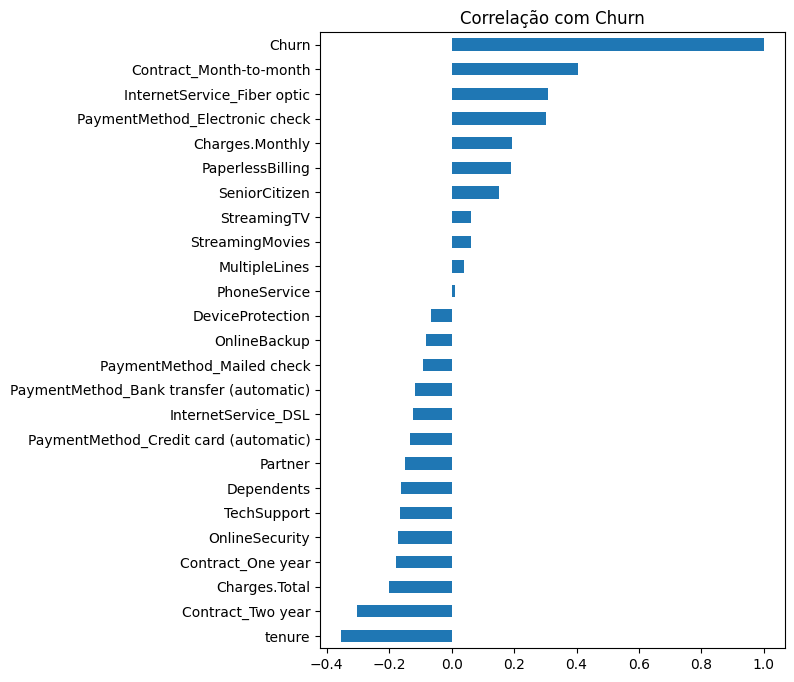

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr()["Churn"].sort_values()

plt.figure(figsize=(6,8))
corr.plot(kind="barh")
plt.title("Correlação com Churn")
plt.show()

##**2.1. Análise do Boxplot: Permanência vs Churn**
O boxplot mostra a distribuição do **tempo de permanência dos clientes (tenure)** em relação ao churn. A partir do gráfico, observa-se que clientes que **não cancelaram o serviço (Churn = 0)** apresentam, em média, um tempo de permanência significativamente maior na empresa. Já os clientes que **cancelaram (Churn = 1)** tendem a possuir um tempo de permanência bem menor.

Isso indica que clientes mais novos possuem maior probabilidade de cancelar o serviço, enquanto clientes que permanecem por mais tempo tendem a continuar utilizando os serviços da empresa. Esse resultado reforça também o que foi observado na análise de correlação, onde a variável tenure apresentou correlação negativa com churn, sugerindo que o tempo de relacionamento com a empresa é um fator importante para a retenção de clientes.

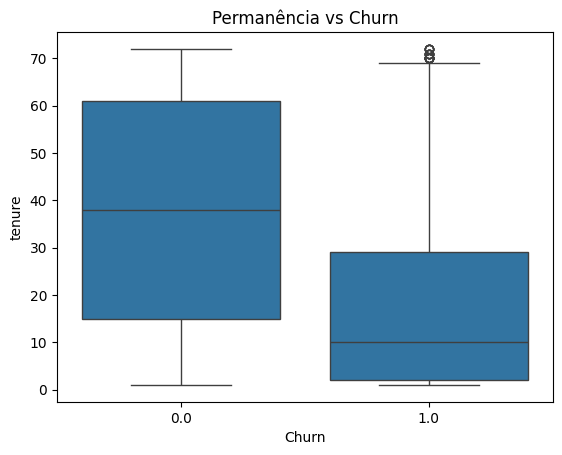

In [52]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Permanência vs Churn")
plt.show()

##**2.2. Análise do Boxplot: Mensalidade vs Churn**
O boxplot mostra a distribuição dos **valores de mensalidade (Charges.Monthly)** em relação ao churn. Observa-se que os clientes que **cancelaram o serviço (Churn = 1)** tendem a apresentar mensalidades mais altas quando comparados aos clientes que **permaneceram na empresa (Churn = 0)**.

A mediana das cobranças mensais para clientes que cancelaram é superior à dos clientes que permaneceram, indicando que valores mais altos de mensalidade podem estar associados a uma maior probabilidade de churn. Esse resultado também está alinhado com a análise de correlação realizada anteriormente, na qual a variável Charges.Monthly apresentou correlação positiva com churn, sugerindo que custos mais elevados podem influenciar na decisão do cliente de cancelar o serviço.

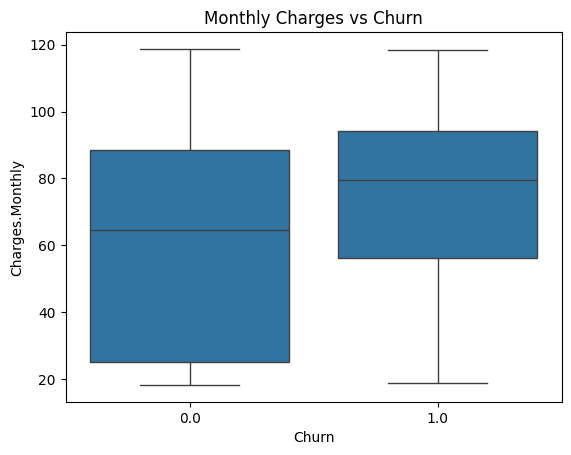

In [53]:
sns.boxplot(x="Churn", y="Charges.Monthly", data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

##**2.3. Análise do Boxplot: Gasto Total vs Churn**
O boxplot apresenta a distribuição do **valor total gasto pelos clientes (Charges.Total)** em relação ao churn. Observa-se que clientes que **não cancelaram o serviço (Churn = 0)** tendem a possuir valores totais de gasto significativamente maiores do que aqueles que **cancelaram (Churn = 1)**.

Isso ocorre porque clientes que permanecem por mais tempo na empresa naturalmente acumulam um valor total de pagamento maior ao longo do tempo. Já os clientes que cancelam geralmente possuem valores totais menores, indicando que muitos deles interrompem o serviço relativamente cedo.

Esse comportamento também está alinhado com a análise de correlação realizada anteriormente, na qual Charges.Total apresentou correlação negativa com churn, sugerindo que clientes com maior valor total gasto tendem a permanecer na empresa por mais tempo.

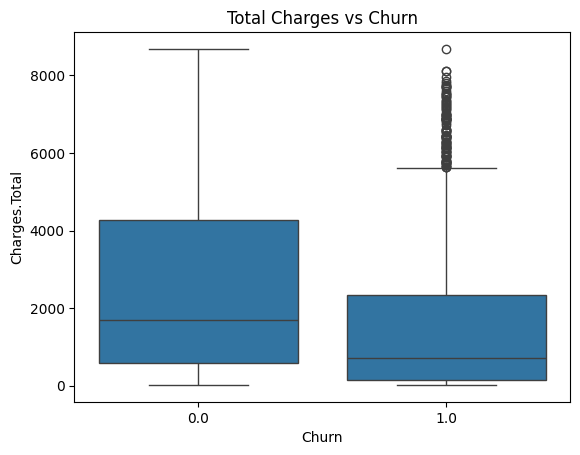

In [54]:
sns.boxplot(x="Churn", y="Charges.Total", data=df)

plt.title("Total Charges vs Churn")
plt.show()

##**2.4. Análise do Pairplot: Permanência, Total Gasto e Churn**
O pairplot permite observar simultaneamente a distribuição das variáveis **tenure** e **Charges.Total**, além da relação entre elas, separando os clientes que **cancelaram (Churn = 1)** e os que **permaneceram (Churn = 0)**.

Observa-se uma relação clara entre **tenure** e **Charges.Total**, onde clientes com maior tempo de permanência tendem a apresentar valores totais de cobrança mais altos. Isso ocorre porque o valor total pago aumenta conforme o cliente permanece mais tempo utilizando o serviço.

Além disso, nota-se que os pontos associados ao churn se concentram principalmente em regiões com menor tempo de permanência e menores valores totais pagos. Já os clientes que não cancelaram tendem a estar distribuídos em áreas com maior tempo de permanência e maior valor acumulado de cobrança.

De forma geral, essa visualização reforça os resultados observados nas análises anteriores, indicando que clientes mais novos possuem maior probabilidade de cancelar o serviço, enquanto clientes com maior tempo de permanência tendem a continuar utilizando os serviços da empresa.

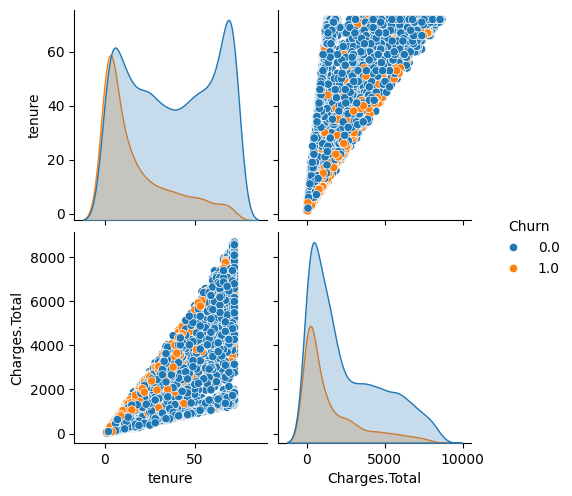

In [55]:
sns.pairplot(
    df[["tenure", "Charges.Total", "Churn"]],
    hue="Churn"
)

#3. Treinamento dos Modelos
Após a etapa de análise exploratória dos dados, iniciou-se a fase de treinamento dos modelos preditivos. O primeiro passo desse processo foi a separação do dataset em conjuntos de treino e teste.

Inicialmente, os dados foram divididos entre **variáveis preditoras (X)** e **variável alvo (y)**. As variáveis preditoras correspondem a todas as colunas utilizadas para realizar a previsão, enquanto a variável Churn representa o resultado que o modelo deve prever.

Em seguida, foi utilizada a função **train_test_split** da biblioteca **scikit-learn** para dividir os dados em dois conjuntos:

* **Treino (80%)**: utilizado para treinar os modelos de machine learning.

* **Teste (20%)**: utilizado para avaliar o desempenho dos modelos em dados que não foram vistos durante o treinamento.

O parâmetro **stratify=y** foi utilizado para garantir que a proporção de clientes com e sem churn seja mantida tanto no conjunto de treino quanto no conjunto de teste. Isso é importante para evitar distorções na distribuição da variável alvo durante o treinamento e avaliação dos modelos.

Por fim, foi definido **random_state=355**, garantindo que a divisão dos dados seja reproduzível caso o experimento seja executado novamente.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=355
)

##**3.1. Dummy Classifier**
O **Dummy Classifier** foi utilizado como modelo de **referência inicial (baseline)**, pois ele realiza previsões simples sem aprender padrões dos dados. Neste caso, foi utilizada a estratégia **strategy="most_frequent"**, que faz com que o modelo sempre preveja a classe mais frequente do conjunto de treinamento. A utilização desse modelo permite estabelecer um nível mínimo de desempenho esperado, servindo como parâmetro para verificar se os modelos mais complexos realmente estão aprendendo informações relevantes do conjunto de dados.

In [57]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)



##**3.2. Árvore de Decisão**
A **Árvore de Decisão** foi selecionada por sua capacidade de capturar relações não lineares entre as variáveis e pela facilidade de interpretação do modelo gerado. Diferentemente de alguns algoritmos lineares, esse método não exige normalização dos dados, pois as decisões são tomadas com base em divisões (splits) nos valores das variáveis. Além disso, árvores de decisão permitem identificar quais atributos possuem maior importância na previsão do churn, auxiliando na compreensão dos fatores que influenciam o comportamento dos clientes.

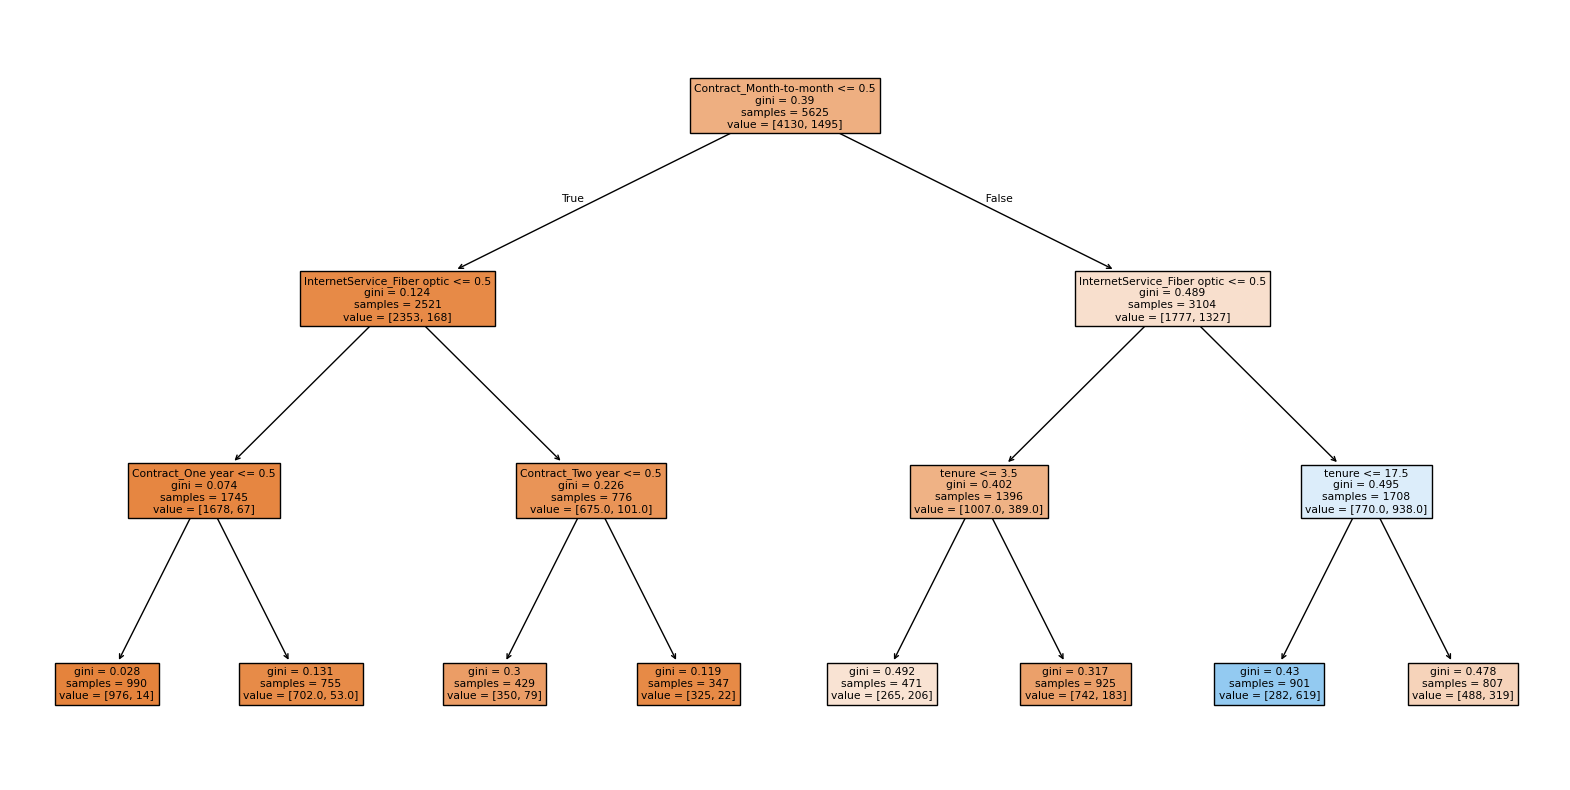

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=355
)

tree.fit(X_train, y_train)
y_tree_pred = tree.predict(X_test)


plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X_train.columns, filled=True)
plt.show()

##**3.3. Regressão Logística**
A **Regressão Logística** foi escolhida por ser um modelo amplamente utilizado em problemas de classificação binária, como a previsão de churn. Esse modelo possui boa interpretabilidade, permitindo compreender como cada variável influencia na probabilidade de um cliente cancelar o serviço. Para a aplicação da Regressão Logística, é importante realizar a **normalização das variáveis numéricas**, pois o modelo utiliza métodos de otimização baseados em gradiente. Quando as variáveis possuem escalas muito diferentes, algumas podem dominar o processo de aprendizado, prejudicando a convergência do algoritmo e a qualidade das estimativas dos coeficientes.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

num_cols = ["tenure", "Charges.Monthly", "Charges.Total"]
scaler = StandardScaler()

X_train_norm = X_train.copy()
X_train_norm[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test_norm = X_test.copy()
X_test_norm[num_cols] = scaler.transform(X_test[num_cols])

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
)

log_reg.fit(X_train_norm, y_train)

y_log_reg_pred = log_reg.predict(X_test_norm)


#4. Avaliação dos modelos

##**4.1. Validação Cruzada**
A validação cruzada foi utilizada para avaliar a capacidade de generalização dos modelos e verificar possíveis problemas de **overfitting**. Os resultados mostram que a média da validação cruzada foi de **aproximadamente 0.79 para a Árvore de Decisão** e **0.75 para a Regressão Logística**, valores muito próximos das acurácias obtidas no **conjunto de teste (0.79 e 0.74, respectivamente)**. Essa pequena diferença indica que os modelos apresentam bom poder de generalização e não demonstram sinais significativos de **overfitting**. Dessa forma, pode-se concluir que ambos os modelos conseguem aprender padrões relevantes dos dados sem simplesmente memorizar o conjunto de treinamen

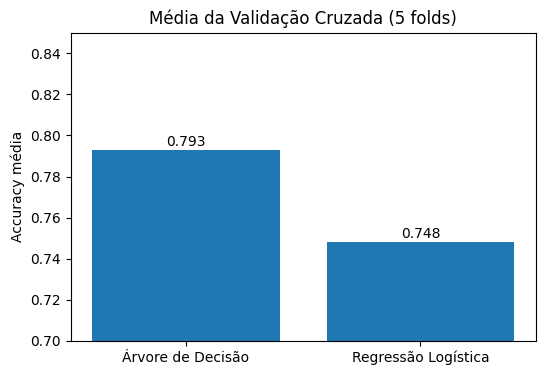

In [60]:
from sklearn.model_selection import cross_val_score

tree_scores = cross_val_score(tree, X_train, y_train, cv=5)
log_scores = cross_val_score(log_reg, X_train_norm, y_train, cv=5)

models = ["Árvore de Decisão", "Regressão Logística"]
means = [tree_scores.mean(), log_scores.mean()]

plt.figure(figsize=(6,4))
plt.bar(models, means)

plt.ylabel("Accuracy média")
plt.title("Média da Validação Cruzada (5 folds)")

for i, v in enumerate(means):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center")

plt.ylim(0.7, 0.85)

plt.show()

##**4.2. Comparação dos modelos**
O **Dummy Classifier** obteve uma acurácia de **0.73**, porém não conseguiu identificar corretamente nenhum caso de churn. Para a classe **1 (clientes que cancelaram)**, o modelo apresentou **precision**, **recall** e **F1-score iguais a 0.00**, pois ele sempre prevê a classe majoritária (não churn). Isso significa que, embora a acurácia pareça razoável, o modelo não possui utilidade prática para o problema, já que não consegue detectar clientes que possivelmente irão cancelar o serviço.

A **Regressão Logística** apresentou uma **acurácia de 0.75**, valor próximo ao obtido pelo **Dummy Classifier**, porém com desempenho significativamente superior na identificação de churn. O modelo alcançou **precision de 0.52**, **recall de 0.79** e **F1-score de 0.63** para a classe de churn. O valor mais alto de **recall** indica que o modelo consegue identificar grande parte dos clientes que cancelam o serviço, enquanto a **precision** moderada mostra que parte das previsões de churn ainda inclui alguns falsos positivos. O **F1-score** representa um equilíbrio entre **precision** e **recall**, indicando um desempenho consistente do modelo na identificação de clientes com risco de churn.

A **Árvore de Decisão** apresentou a maior acurácia geral entre os modelos, com **0.78**, além de um bom desempenho na identificação de clientes que **não cancelaram o serviço (recall de 0.93 para a classe 0)**. Para a classe de churn, o modelo apresentou **precision de 0.65**, **recall de 0.37** e **F1-score de 0.47**. Isso significa que, embora quando o modelo prevê churn ele tende a estar mais correto (**precision** maior), ele identifica apenas uma parte dos clientes que realmente cancelam o serviço. Como resultado, o **F1-score** acaba sendo inferior ao da **Regressão Logística**, indicando um desempenho menos equilibrado para a detecção de churn.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


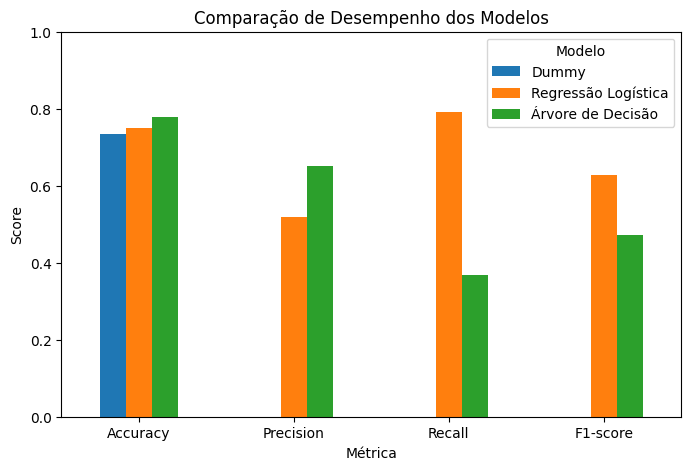

In [61]:
dummy_report = classification_report(y_test, y_dummy_pred, output_dict=True)
log_reg_report = classification_report(y_test, y_log_reg_pred, output_dict=True)
tree_report = classification_report(y_test, y_tree_pred, output_dict=True)

metrics_df = pd.DataFrame({
    "Dummy": [
        dummy_report["accuracy"],
        dummy_report["1.0"]["precision"],
        dummy_report["1.0"]["recall"],
        dummy_report["1.0"]["f1-score"]
    ],
    "Regressão Logística": [
        log_reg_report["accuracy"],
        log_reg_report["1.0"]["precision"],
        log_reg_report["1.0"]["recall"],
        log_reg_report["1.0"]["f1-score"]
    ],
    "Árvore de Decisão": [
        tree_report["accuracy"],
        tree_report["1.0"]["precision"],
        tree_report["1.0"]["recall"],
        tree_report["1.0"]["f1-score"]
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])

metrics_df.plot(kind="bar", figsize=(8,5))

plt.title("Comparação de Desempenho dos Modelos")
plt.ylabel("Score")
plt.xlabel("Métrica")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(title="Modelo")

plt.show()

##**4.3. Matriz de Confusão**
A matriz de confusão é utilizada para avaliar modelos de classificação ao mostrar não apenas a quantidade de previsões corretas, mas também os tipos de erros cometidos. Ela apresenta quatro resultados principais: **verdadeiros negativos (TN)**, quando o modelo prevê corretamente clientes que não cancelaram; **verdadeiros positivos (TP)**, quando identifica corretamente clientes que cancelaram; **falsos positivos (FP)**, quando prevê churn para clientes que permaneceram; e **falsos negativos (FN)**, quando não consegue identificar clientes que realmente cancelaram.

###4.3.1. Regressão Logística
A matriz de confusão da **Regressão Logística** mostra como o modelo classificou corretamente e incorretamente os casos de churn e não churn. Dos 1033 clientes que não cancelaram o serviço, o modelo classificou corretamente 759 como não churn, enquanto 274 foram classificados incorretamente como churn. Já entre os 374 clientes que realmente cancelaram, o modelo identificou corretamente 296 casos, enquanto 78 foram classificados incorretamente como não churn.

Esses resultados indicam que o modelo possui boa capacidade de identificar clientes que cancelam o serviço, já que conseguiu detectar a maior parte dos casos reais de churn. No entanto, também há uma quantidade considerável de **falsos positivos**, ou seja, clientes que foram classificados como churn mesmo sem terem cancelado o serviço. Ainda assim, para um problema de previsão de churn, identificar corretamente clientes com risco de cancelamento é um aspecto importante para permitir ações preventivas por parte da empresa.

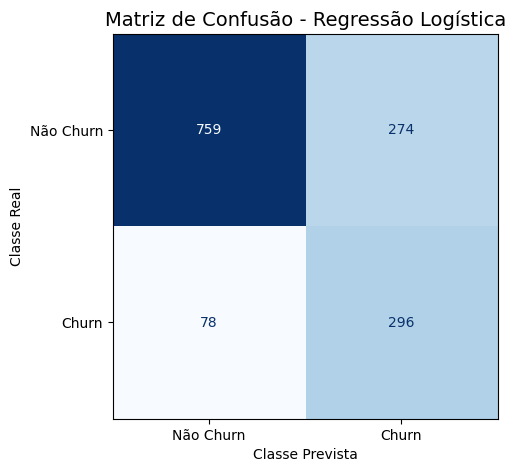

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test, y_log_reg_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Não Churn", "Churn"]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusão - Regressão Logística", fontsize=14)
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

###4.3.2. Árvore de Decisão
A matriz de confusão da **Árvore de Decisão** mostra como o modelo classificou os casos de churn e não churn. Dos 1033 clientes que não cancelaram o serviço, o modelo classificou corretamente 959 como não churn, enquanto 74 foram classificados incorretamente como churn. Já entre os 374 clientes que realmente cancelaram, apenas 138 foram identificados corretamente, enquanto 236 foram classificados incorretamente como não churn.

Esses resultados indicam que a Árvore de Decisão apresenta alto desempenho na identificação de clientes que não cancelam o serviço, cometendo poucos erros nessa classe. No entanto, o modelo possui dificuldade em identificar clientes que realmente cancelam, deixando de detectar uma quantidade significativa de casos de churn. Isso reforça o que foi observado nas métricas anteriores, onde o modelo apresentou um **recall** baixo para a classe de churn, indicando menor capacidade de detectar clientes com risco de cancelamento.

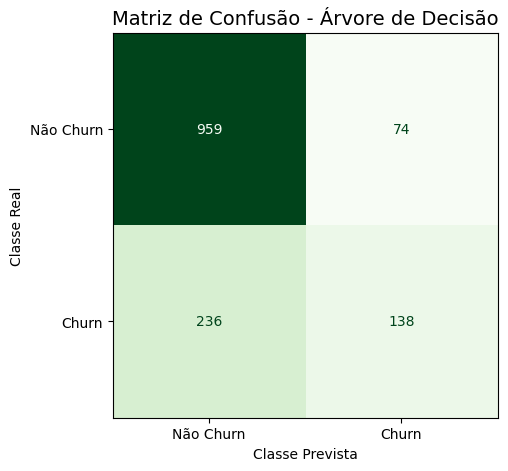

In [63]:
cm_tree = confusion_matrix(y_test, y_tree_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Não Churn", "Churn"]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Greens",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusão - Árvore de Decisão", fontsize=14)
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

##**4.4. Conclusão da Comparação**
A comparação dos modelos mostra diferenças importantes entre as métricas de avaliação. A **Regressão Logística** apresentou uma acurácia de **0.75**, com melhor equilíbrio entre **precision**, **recall** e **F1-score** para a classe de churn. O modelo obteve **precision de 0.52**, **recall de 0.79** e **F1-score de 0.63** para essa classe, destacando-se especialmente no **recall**, o que indica uma boa capacidade de identificar clientes que realmente cancelam o serviço. Esse comportamento é importante em problemas de churn, pois permite que a empresa identifique a maior parte dos clientes com risco de cancelamento.

A **Árvore de Decisão** apresentou uma acurácia geral ligeiramente maior (**0.78**) e bons resultados na identificação de clientes que não cancelaram o serviço (**recall de 0.93 para a classe 0**). No entanto, para a classe de churn o modelo apresentou **precision de 0.65**, **recall de 0.37** e **F1-score de 0.47**, indicando dificuldade em identificar corretamente muitos dos clientes que realmente cancelam o serviço.

A matriz de confusão reforça essa análise. Embora a **Árvore de Decisão** identifique corretamente mais clientes que permanecem no serviço, ela gera um número elevado de **falsos negativos (236)**, ou seja, clientes que cancelam mas não são detectados pelo modelo. Já a **Regressão Logística** apresenta menos **falsos negativos (78)** e identifica **296 casos reais de churn**, mostrando maior capacidade de detectar clientes com risco de cancelamento.

Dessa forma, considerando o objetivo do projeto de identificar clientes com maior probabilidade de churn, a **Regressão Logística** se mostra o modelo mais adequado. Apesar de possuir uma acurácia geral um pouco menor que a **Árvore de Decisão**, ela apresenta maior **recall** e melhor **F1-score** para a classe de churn, sendo mais eficiente em detectar clientes que realmente podem cancelar o serviço. Isso a torna mais útil para aplicações práticas de retenção de clientes, onde identificar esses casos com antecedência é fundamental para que a empresa possa adotar estratégias de prevenção.

#5. Seleção de Variáveis com RFECV
Seleção de Variáveis com **RFECV**

Após a comparação dos modelos, foi realizada uma etapa de otimização das variáveis utilizadas no treinamento, com o objetivo de identificar quais colunas do dataset realmente contribuem para a previsão de churn. Para isso, foi utilizado o método **RFECV (Recursive Feature Elimination with Cross-Validation)**, disponível na biblioteca **scikit-learn**.

O **RFECV** funciona removendo iterativamente as variáveis menos relevantes para o modelo e avaliando o desempenho a cada etapa por meio de **validação cruzada**. Nesse processo, foi utilizada a **Regressão Logística** como estimador base e a métrica **F1-score** como critério de avaliação, por ser uma métrica que equilibra **precision e recall**, sendo adequada para problemas de classificação com classes desbalanceadas.

O objetivo dessa etapa é reduzir o número de variáveis utilizadas pelo modelo, mantendo apenas aquelas que realmente contribuem para a previsão. Isso pode trazer benefícios como **redução de ruído** nos dados, **modelos mais simples e interpretáveis e menor risco de overfitting**.

Ao final do processo, as seguintes variáveis foram removidas por apresentarem menor contribuição para o desempenho do modelo:

* **StreamingTV**

* **Partner**

* **MultipleLines**

* **PaymentMethod_Bank transfer (automatic)**

* **StreamingMovies**

* **PaymentMethod_Credit card (automatic)**

* **PaymentMethod_Mailed check**

* **Contract_One year**

In [64]:
from sklearn.feature_selection import RFECV

model = LogisticRegression(max_iter=1000, class_weight="balanced")

rfecv = RFECV(
    estimator=model,
    step=1,
    cv=5,
    scoring="f1"
)

rfecv.fit(X_train_norm, y_train)

melhores_colunas = X_train_norm.columns[rfecv.support_]
X_train = X_train[melhores_colunas]
X_test = X_test[melhores_colunas]
X_train_norm = X_train_norm[melhores_colunas]
X_test_norm = X_test_norm[melhores_colunas]

['StreamingTV', 'Partner', 'MultipleLines', 'PaymentMethod_Bank transfer (automatic)', 'StreamingMovies', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check', 'Contract_One year']


##**5.1. Retreinando Modelos**
Primeiramente, os modelos de **Regressão Logística** e **Árvore de Decisão** foram treinados novamente utilizando os conjuntos de treino atualizados. Em seguida, foram realizadas novas previsões no conjunto de teste para avaliar o desempenho dos modelos após a redução das variáveis.

Esse processo permite verificar se o modelo consegue manter ou melhorar sua capacidade preditiva utilizando menos informações, o que contribui para modelos mais eficientes, interpretáveis e com menor risco de overfitting.

In [66]:
log_reg.fit(X_train_norm, y_train)
tree.fit(X_train, y_train)

y_tree_pred = tree.predict(X_test)
y_log_reg_pred = log_reg.predict(X_test_norm)


Dummy:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85      1033
         1.0       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1033
         1.0       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

Decision Tree:
               precision    recall  f1-score   support

         0.0       0.80      0.93      0.86      1033
         1.0       0.65      0.37      0.47       374

    accuracy                           0.78      1407
   macro avg       0.73      0.65      0.67      1407
weighted avg       0.76     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##**5.2. Comparando Modelos**
Após o retreinamento dos modelos utilizando apenas as variáveis selecionadas pelo RFECV, observa-se que não houve alterações nos valores das métricas de desempenho quando comparados aos resultados obtidos anteriormente. A **Regressão Logística** manteve **acurácia de 0.75**, **precision de 0.52**, **recall de 0.79** e **F1-score de 0.63** para a classe de churn, enquanto a **Árvore de Decisão** permaneceu com **acurácia de 0.78**, **precision de 0.65**, **recall de 0.37** e **F1-score de 0.47** para essa mesma classe.

Isso indica que as variáveis removidas durante a etapa de seleção não estavam contribuindo de forma significativa para o desempenho dos modelos. Dessa forma, foi possível reduzir o número de variáveis utilizadas sem impactar negativamente os resultados, resultando em modelos mais simples e potencialmente mais eficientes, mantendo o mesmo desempenho preditivo observado anteriormente.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


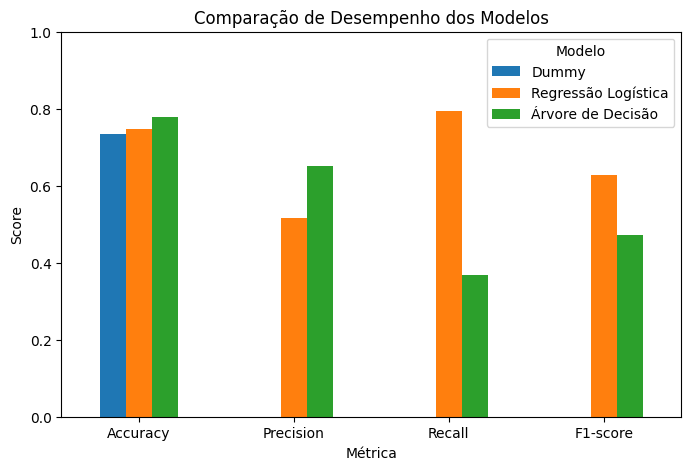

In [67]:
dummy_report = classification_report(y_test, y_dummy_pred, output_dict=True)
log_reg_report = classification_report(y_test, y_log_reg_pred, output_dict=True)
tree_report = classification_report(y_test, y_tree_pred, output_dict=True)

metrics_df = pd.DataFrame({
    "Dummy": [
        dummy_report["accuracy"],
        dummy_report["1.0"]["precision"],
        dummy_report["1.0"]["recall"],
        dummy_report["1.0"]["f1-score"]
    ],
    "Regressão Logística": [
        log_reg_report["accuracy"],
        log_reg_report["1.0"]["precision"],
        log_reg_report["1.0"]["recall"],
        log_reg_report["1.0"]["f1-score"]
    ],
    "Árvore de Decisão": [
        tree_report["accuracy"],
        tree_report["1.0"]["precision"],
        tree_report["1.0"]["recall"],
        tree_report["1.0"]["f1-score"]
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])

metrics_df.plot(kind="bar", figsize=(8,5))

plt.title("Comparação de Desempenho dos Modelos")
plt.ylabel("Score")
plt.xlabel("Métrica")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(title="Modelo")

plt.show()

#6. Otimização de Hiperparâmetros com Grid Search
Após a seleção das variáveis e o retreinamento dos modelos, foi realizada uma etapa de otimização dos **hiperparâmetros** utilizando a técnica de **Grid Search**. Essa abordagem consiste em testar automaticamente diferentes combinações de parâmetros dos modelos para identificar quais configurações produzem o melhor desempenho.

O processo é realizado em conjunto com validação cruzada, garantindo que cada combinação de parâmetros seja avaliada de forma robusta em diferentes divisões dos dados. Dessa forma, é possível encontrar uma configuração que melhore a capacidade de generalização do modelo.

O objetivo dessa etapa é ajustar os parâmetros dos modelos para obter o melhor desempenho possível, aumentando a precisão das previsões sem alterar os dados de treinamento.

##**6.1. Otimização da Árvore de Decisão**
Nesta etapa foi realizada a otimização dos **hiperparâmetros da Árvore de Decisão** utilizando o método **Grid Search**. Foram testadas diferentes combinações de valores para os parâmetros **max_depth**, **min_samples_split** e **min_samples_leaf**, que controlam a complexidade da árvore e influenciam diretamente na capacidade do modelo de generalizar os dados.

A busca foi realizada utilizando validação cruzada com **5 folds** e a métrica **F1-score** como critério de avaliação, pois essa métrica considera o equilíbrio entre **precision e recall**, sendo adequada para problemas de classificação com classes desbalanceadas.

Após testar todas as combinações de parâmetros definidas no grid, o melhor conjunto de hiperparâmetros encontrado foi:

* **max_depth = 5**

* **min_samples_split = 2**

* **min_samples_leaf = 4**

In [68]:
from sklearn.model_selection import GridSearchCV

param_grid_tree = {
    "max_depth": [3,5,7,10],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

grid_tree = GridSearchCV(
    tree,
    param_grid_tree,
    cv=5,
    scoring="f1"
)

grid_tree.fit(X_train, y_train)

{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


##**6.2. Otimização da Regressão Logística**
Na sequência, foi realizada a otimização dos **hiperparâmetros do modelo de Regressão Logística** utilizando **Grid Search**. Nessa etapa, foram testadas diferentes combinações de parâmetros que influenciam na regularização e no tratamento do desbalanceamento das classes.

Entre os parâmetros avaliados estão:

* **C**: controla a força da regularização do modelo. Valores menores indicam maior regularização, reduzindo o risco de overfitting.

* **penalty**: define o tipo de regularização aplicada ao modelo (L1 ou L2).

* **solver**: algoritmo utilizado para realizar a otimização do modelo.

* **class_weight**: define pesos para as classes, podendo ajudar em problemas com desbalanceamento de dados, como ocorre no caso do churn.

Assim como na otimização da **Árvore de Decisão**, foi utilizada **validação cruzada com 5 folds** e a métrica **F1-score** como critério de avaliação.

Após testar todas as combinações definidas no grid, o melhor conjunto de hiperparâmetros encontrado foi:

* **C = 0.1**

* **penalty = l2**

* **solver = liblinear**

* **class_weight = balanced**

In [69]:
from sklearn.linear_model import LogisticRegression

param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_log,
    cv=5,
    scoring="f1"
)

grid_log.fit(X_train_norm, y_train)

print("Best parameters:", grid_log.best_params_)

Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


##**6.3. Treinamento com os Hiperparâmetros**
Após a etapa de otimização dos **hiperparâmetros** com **Grid Search**, os modelos foram novamente treinados utilizando as melhores configurações encontradas durante o processo de busca.

Para isso, foram utilizados os estimadores retornados pelo atributo **best_estimator_** de cada objeto do **Grid Search**. Esse atributo contém o modelo já configurado com o conjunto de **hiperparâmetros** que apresentou o melhor desempenho durante a **validação cruzada**.

Assim, tanto a **Árvore de Decisão** quanto a **Regressão Logística** foram treinadas novamente com os dados de treino, agora utilizando essas configurações otimizadas. Em seguida, foram realizadas novas predições no conjunto de teste, permitindo avaliar se a otimização dos parâmetros trouxe melhorias no desempenho dos modelos.

In [70]:
tree = grid_tree.best_estimator_
tree.fit(X_train, y_train)

log_reg = grid_log.best_estimator_
log_reg.fit(X_train_norm, y_train)

y_tree_pred = tree.predict(X_test)
y_log_reg_pred = log_reg.predict(X_test_norm)

Dummy:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85      1033
         1.0       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1033
         1.0       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407

Decision Tree:
               precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      1033
         1.0       0.59      0.59      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##**6.4. Comparação dos Modelos**
Após a otimização dos **hiperparâmetros** e o novo treinamento dos modelos, é possível observar algumas mudanças principalmente no desempenho da **Árvore de Decisão**, enquanto os resultados da **Regressão Logística** permaneceram praticamente inalterados.

No caso da **Regressão Logística**, todas as métricas permaneceram iguais às obtidas anteriormente. O modelo manteve **acurácia de 0.75**, **recall de 0.79** para a classe de churn, **precision de 0.52** e **F1-score de 0.62** para essa classe. Isso indica que a configuração encontrada pelo **Grid Search** é muito próxima da configuração já utilizada anteriormente, não trazendo mudanças perceptíveis no desempenho do modelo.

Já a **Árvore de Decisão** apresentou mudanças mais relevantes. Antes da otimização, o modelo possuía **recall de 0.37** para a classe de churn, enquanto após a otimização esse valor aumentou para **0.59**, representando uma melhora significativa na capacidade do modelo de identificar clientes que cancelam o serviço. O **F1-score** da classe de churn também aumentou de **0.47** para **0.59**, indicando um melhor equilíbrio entre **precisão e recall**. Por outro lado, o recall da classe de não churn diminuiu, passando de **0.93** para **0.85**, o que mostra que o modelo passou a cometer um pouco mais de erros ao prever clientes que permanecem no serviço.

De forma geral, a otimização dos **hiperparâmetros** tornou a Árvo**re de Decisão** mais equilibrada entre as classes, melhorando a identificação de churn sem alterar significativamente a acurácia geral do modelo, que permaneceu em **0.78**.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


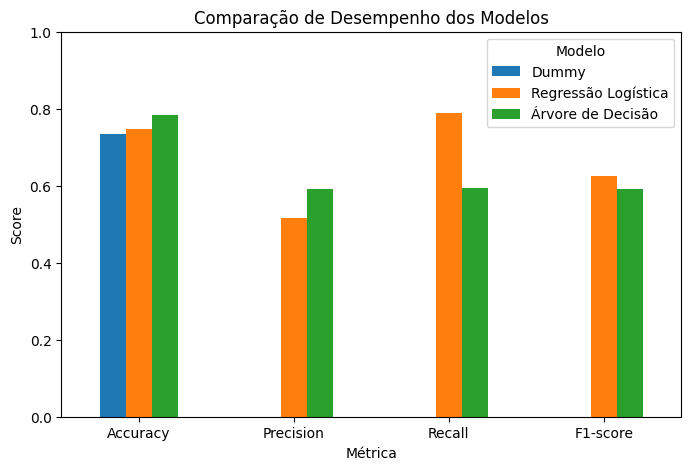

In [71]:
dummy_report = classification_report(y_test, y_dummy_pred, output_dict=True)
log_reg_report = classification_report(y_test, y_log_reg_pred, output_dict=True)
tree_report = classification_report(y_test, y_tree_pred, output_dict=True)

metrics_df = pd.DataFrame({
    "Dummy": [
        dummy_report["accuracy"],
        dummy_report["1.0"]["precision"],
        dummy_report["1.0"]["recall"],
        dummy_report["1.0"]["f1-score"]
    ],
    "Regressão Logística": [
        log_reg_report["accuracy"],
        log_reg_report["1.0"]["precision"],
        log_reg_report["1.0"]["recall"],
        log_reg_report["1.0"]["f1-score"]
    ],
    "Árvore de Decisão": [
        tree_report["accuracy"],
        tree_report["1.0"]["precision"],
        tree_report["1.0"]["recall"],
        tree_report["1.0"]["f1-score"]
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])

metrics_df.plot(kind="bar", figsize=(8,5))

plt.title("Comparação de Desempenho dos Modelos")
plt.ylabel("Score")
plt.xlabel("Métrica")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(title="Modelo")

plt.show()

##**6.5. Matriz de Confusão**

###6.5.1. Regressão Lógistica
Comparando a matriz de confusão da **Regressão Logística** antes e depois da otimização, observa-se que as mudanças foram mínimas, indicando que a otimização dos **hiperparâmetros** praticamente não alterou o comportamento do modelo.

Antes da otimização, os resultados eram:

* **759 verdadeiros negativos**

* **274 falsos positivos**

* **78 falsos negativos**

* **296 verdadeiros positivos**

Após a otimização, os resultados passaram a ser:

* **757 verdadeiros negativos**

* **276 falsos positivos**

* **79 falsos negativos**

* **295 verdadeiros positivos**

Portanto, houve apenas pequenas **variações de 1 ou 2** registros entre as categorias, com uma leve redução nos **verdadeiros negativos e verdadeiros positivos**, e um pequeno aumento nos **falsos positivos e falsos negativos**. Essas diferenças são muito pequenas e não impactam de forma significativa o desempenho geral do modelo, o que confirma o que já havia sido observado nas métricas de avaliação: a **Regressão Logística** manteve praticamente o mesmo desempenho mesmo após a etapa de otimização dos hiperparâmetros.

[[Text(0, 0, '757') Text(1, 0, '276')]
 [Text(0, 1, '79') Text(1, 1, '295')]]


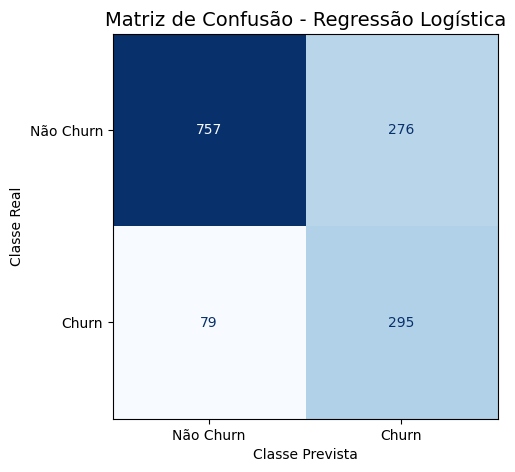

In [74]:
cm_log = confusion_matrix(y_test, y_log_reg_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Não Churn", "Churn"]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusão - Regressão Logística", fontsize=14)
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

###6.5.2. Árvore de Decisão
Comparando a matriz de confusão da **Árvore de Decisão** antes e depois da otimização, é possível observar mudanças mais significativas no comportamento do modelo.

Antes da otimização, os resultados eram:

* **959 verdadeiros negativos**

* **74 falsos positivos**

* **236 falsos negativos**

* **138 verdadeiros positivos**

Após a otimização, os resultados passaram a ser:

* **879 verdadeiros negativos**

* **154 falsos positivos**

* **152 falsos negativos**

* **222 verdadeiros positivos**

A principal mudança está na melhoria na identificação de clientes que cancelam o serviço. O número de **verdadeiros positivos** aumentou de **138 para 222**, enquanto os **falsos negativos** diminuíram de **236 para 152**, o que indica que o modelo passou a detectar uma quantidade maior de casos reais de churn.

Por outro lado, essa melhoria veio acompanhada de um aumento nos **falsos positivos**, que passaram de **74 para 154**, além de uma redução nos **verdadeiros negativos**. Isso significa que o modelo passou a classificar mais clientes como churn, inclusive alguns que na realidade não cancelariam o serviço.

De forma geral, a otimização tornou a **Árvore de Decisão** mais sensível à detecção de churn, reduzindo significativamente os casos de churn não identificados. Isso melhora o **recall** da classe de churn, tornando o modelo mais adequado para cenários onde é mais importante identificar clientes com risco de cancelamento, mesmo que isso gere alguns alarmes falsos adicionais.

[[Text(0, 0, '879') Text(1, 0, '154')]
 [Text(0, 1, '152') Text(1, 1, '222')]]


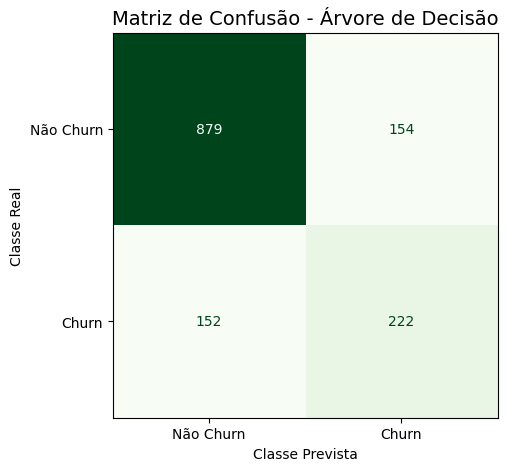

In [76]:
cm_tree = confusion_matrix(y_test, y_tree_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Não Churn", "Churn"]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Greens",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Matriz de Confusão - Árvore de Decisão", fontsize=14)
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.show()

##**6.6. Conclusão da Comparação**
A etapa de otimização de **hiperparâmetros** contribuiu para melhorar o desempenho da **Árvore de Decisão**, principalmente na identificação de clientes que realizam churn. Após a otimização, o modelo apresentou um aumento significativo no número de **verdadeiros positivos** e uma redução nos **falsos negativos**, o que resultou em uma melhora no **recall e no F1-score** da classe de churn. Isso indica que o ajuste dos parâmetros permitiu que o modelo se tornasse mais sensível à detecção de clientes com risco de cancelamento.

Entretanto, mesmo com essa melhoria, a **Regressão Logística** ainda apresentou desempenho superior na detecção de churn, mantendo um **recall** mais alto e um melhor equilíbrio entre as métricas de avaliação. Além disso, a otimização da **Regressão Logística** não gerou mudanças relevantes em seus resultados, indicando que o modelo já se encontrava em uma configuração próxima do ideal.

Dessa forma, embora a **hiperparametrização** tenha tornado a **Árvore de Decisão** mais equilibrada e eficiente, a **Regressão Logística** continua sendo o modelo mais adequado para o objetivo do estudo, por demonstrar maior capacidade de identificar corretamente clientes com risco de cancelamento.

#7. Análise da importância das Variáveis
Na etapa final da análise, é realizada a avaliação da importância das variáveis utilizadas pelos modelos. Essa análise tem como objetivo identificar quais características dos clientes mais influenciam na previsão de churn, permitindo compreender melhor quais fatores estão mais relacionados ao cancelamento do serviço.

Além de contribuir para a interpretação dos modelos, essa etapa também é importante para gerar insights de negócio, pois ajuda a empresa a entender quais aspectos do serviço ou do perfil do cliente podem estar associados a um maior risco de cancelamento. Dessa forma, os resultados podem auxiliar na criação de estratégias de retenção mais direcionadas e eficazes.

##**7.1. Regressão Lógistica**
Para analisar a importância das variáveis na **Regressão Logística**, foram utilizados os **coeficientes** gerados pelo modelo após o treinamento. Na **Regressão Logística**, cada variável recebe um coeficiente que indica o quanto ela influencia na probabilidade de churn. Coeficientes positivos indicam aumento da probabilidade de cancelamento, enquanto coeficientes negativos indicam redução dessa probabilidade. Para avaliar a relevância de cada variável, foi considerada a magnitude absoluta dos coeficientes.

Entre as variáveis com maior influência no modelo, destacam-se:

* **tenure (-0.99)** – clientes com maior tempo de permanência têm menor probabilidade de churn.

* **PhoneService (-0.83)** – clientes que utilizam o serviço de telefone tendem a permanecer mais.

* **Charges.Monthly (0.74)** – mensalidades mais altas estão associadas a maior chance de churn.

* **Contract_Month-to-month (0.69)** – contratos mensais aumentam a probabilidade de cancelamento.

* **Contract_Two year (-0.68)** – contratos de longo prazo reduzem o risco de churn.

* **OnlineSecurity (-0.49)** – clientes com esse serviço apresentam menor tendência a cancelar.

* **TechSupport (-0.44)** – suporte técnico também está associado a maior retenção.

De forma geral, os resultados mostram que tempo de permanência, tipo de contrato, valor da mensalidade e serviços adicionais são fatores importantes para explicar o comportamento de churn dos clientes.

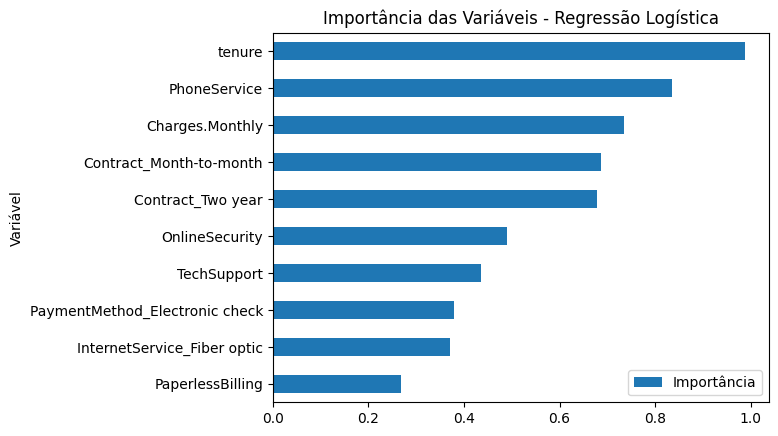

                          Variável  Coeficiente  Importância
7                           tenure    -0.988420     0.988420
8                     PhoneService    -0.834974     0.834974
14                 Charges.Monthly     0.735503     0.735503
2          Contract_Month-to-month     0.686611     0.686611
3                Contract_Two year    -0.679322     0.679322
9                   OnlineSecurity    -0.489924     0.489924
12                     TechSupport    -0.435579     0.435579
4   PaymentMethod_Electronic check     0.378693     0.378693
1      InternetService_Fiber optic     0.369937     0.369937
13                PaperlessBilling     0.267658     0.267658
15                   Charges.Total     0.259281     0.259281
5                    SeniorCitizen     0.255667     0.255667
10                    OnlineBackup    -0.218544     0.218544
11                DeviceProtection    -0.195210     0.195210
0              InternetService_DSL     0.172306     0.172306
6                       

In [79]:
coef = log_reg.coef_[0]

importance_log = pd.DataFrame({
    "Variável": X_train_norm.columns,
    "Coeficiente": coef
})

importance_log["Importância"] = importance_log["Coeficiente"].abs()
importance_log = importance_log.sort_values(by="Importância", ascending=False)

importance_log.head(10).plot(
    x="Variável",
    y="Importância",
    kind="barh"
)

plt.title("Importância das Variáveis - Regressão Logística")
plt.gca().invert_yaxis()
plt.show()

##**7.2. Árvore de Decisão**
Para analisar a importância das variáveis na **Árvore de Decisão**, foi utilizado o valor de **feature importance** gerado pelo próprio modelo. Diferente da **Regressão Logística**, que utiliza coeficientes, a **Árvore de Decisão** calcula a importância de cada variável com base no quanto ela contribui para reduzir a impureza nas divisões da árvore. Em outras palavras, variáveis que ajudam mais o modelo a separar corretamente os dados recebem maior valor de importância.

Entre as variáveis com maior influência no modelo, destacam-se:

* **Contract_Month-to-month (0.51)** – foi a variável mais importante, indicando que clientes com contratos mensais possuem maior probabilidade de churn.

* **tenure (0.18)** – clientes com maior tempo de permanência tendem a cancelar menos.

* **InternetService_Fiber optic (0.17)** – o tipo de serviço de internet também apresenta influência relevante na previsão de churn.

* **Charges.Monthly (0.04)** – valores mensais mais altos estão associados a maior chance de cancelamento.

* **Charges.Total (0.04)** – o gasto total do cliente também contribui para a decisão do modelo.

* **PaymentMethod_Electronic check (0.02)** – o método de pagamento apresenta alguma influência na previsão.

Os resultados mostram que, para a **Árvore de Decisão**, o tipo de contrato é o fator mais determinante para prever churn, seguido pelo tempo de permanência e pelo tipo de serviço de internet. Algumas variáveis apresentaram importância muito baixa ou nula, indicando que tiveram pouca ou nenhuma influência nas decisões do modelo.

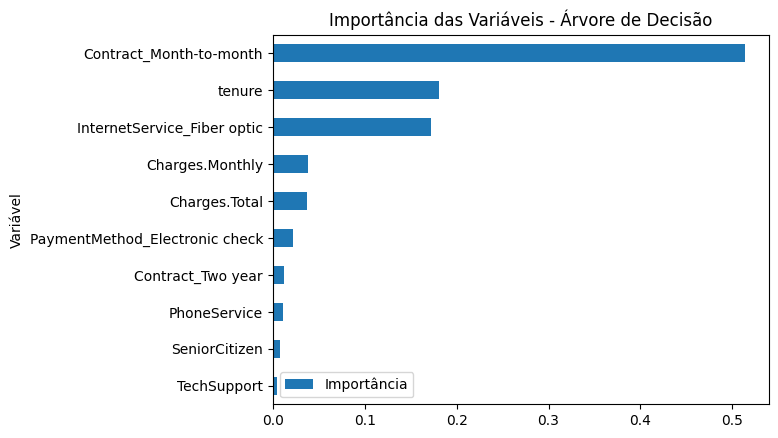

                          Variável  Importância
2          Contract_Month-to-month     0.513892
7                           tenure     0.181022
1      InternetService_Fiber optic     0.172293
14                 Charges.Monthly     0.038126
15                   Charges.Total     0.037411
4   PaymentMethod_Electronic check     0.021792
3                Contract_Two year     0.011752
8                     PhoneService     0.011369
5                    SeniorCitizen     0.007507
12                     TechSupport     0.004172
9                   OnlineSecurity     0.000663
0              InternetService_DSL     0.000000
6                       Dependents     0.000000
10                    OnlineBackup     0.000000
11                DeviceProtection     0.000000
13                PaperlessBilling     0.000000


In [81]:
importance_tree = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": tree.feature_importances_
})

importance_tree = importance_tree.sort_values(by="Importância", ascending=False)

importance_tree.head(10).plot(
    x="Variável",
    y="Importância",
    kind="barh"
)

plt.title("Importância das Variáveis - Árvore de Decisão")
plt.gca().invert_yaxis()
plt.show()

#8. Conclusão
Ao longo desta análise foi desenvolvido um processo completo de **exploração de dados**, **treinamento de modelos** e **interpretação de resultados** com o objetivo de identificar padrões relacionados à evasão de clientes (churn) e compreender quais fatores mais influenciam esse comportamento.

##**8.1. Análise exploratória**
Inicialmente foram realizadas análises exploratórias e comparações entre variáveis relevantes, como **tempo de permanência (tenure)**, **valor da mensalidade (Charges.Monthly)** e **gasto total do cliente (Charges.Total)**. Essas análises mostraram que clientes com menor tempo de permanência e mensalidades mais altas tendem a apresentar maior probabilidade de cancelar o serviço. Também foi observado que clientes que permanecem por mais tempo acumulam maiores valores de gasto total e apresentam menor taxa de churn, indicando que a fidelização aumenta conforme o tempo de relacionamento com a empresa.

##**8.2. Modelagem**
Na etapa de modelagem foram avaliados três modelos de classificação: **Dummy Classifier**, **Regressão Logística** e **Árvore de Decisão**. O **Dummy Classifier** foi utilizado apenas como **baseline**, prevendo sempre a classe majoritária e obtendo acurácia de aproximadamente **0.73**, porém sem conseguir identificar casos de churn.

Entre os modelos treinados, a **Regressão Logística** apresentou o melhor desempenho para a detecção de churn, alcançando **recall** de aproximadamente **0.79** para a classe de churn, além de um bom equilíbrio entre **precision, recall e F1-score**. A **Árvore de Decisão** apresentou maior acurácia geral, porém inicialmente teve dificuldade em identificar clientes que cancelam o serviço. Após a etapa de otimização de hiperparâmetros, o desempenho da **Árvore de Decisão** melhorou significativamente na identificação de churn, aumentando seu **recall e F1-score** para essa classe. Mesmo assim, a **Regressão Logística** continuou apresentando melhor capacidade de detecção de clientes com risco de cancelamento, tornando-se o modelo mais adequado para o objetivo da análise.

##**8.3 Importância das Variáveis**
A análise de importância das variáveis também permitiu identificar os fatores que mais influenciam o churn. Tanto a **Regressão Logística** quanto a **Árvore de Decisão** indicaram padrões semelhantes, destacando principalmente as seguintes variáveis:

Principais fatores associados ao churn:

* **Contract_Month-to-month** – contratos mensais apresentam maior probabilidade de cancelamento.

* **tenure** – clientes com menor tempo de permanência tendem a cancelar com mais frequência.

* **Charges.Monthly** – mensalidades mais altas aumentam o risco de churn.

* **InternetService_Fiber optic** – o tipo de serviço de internet pode influenciar a satisfação do cliente.

* **PaymentMethod_Electronic check** – determinados métodos de pagamento apresentam maior associação com churn.

* **OnlineSecurity e TechSupport** – a presença desses serviços adicionais está relacionada a menor probabilidade de cancelamento.

Esses resultados indicam que fatores contratuais, valor do serviço e tempo de relacionamento com a empresa são elementos fundamentais para explicar o comportamento de evasão dos clientes.

##**8.4. Estratégias de Retenção Baseadas nos Resultados**
Com base nos fatores identificados, algumas estratégias podem ser propostas para reduzir o churn:

1. **Incentivar contratos de longo prazo**
Clientes com contratos mensais apresentaram maior taxa de cancelamento. A empresa pode oferecer descontos, benefícios ou vantagens exclusivas para contratos anuais ou bienais, incentivando maior fidelização.

2. **Atuar nos primeiros meses do cliente**
O tempo de permanência foi um dos fatores mais importantes. Programas de onboarding, acompanhamento inicial e suporte ativo nos primeiros meses podem ajudar a reduzir cancelamentos precoces.

3. **Revisar estratégias de precificação**
Mensalidades mais altas estão associadas a maior risco de churn. Avaliar planos mais flexíveis ou promoções personalizadas pode ajudar a reter clientes sensíveis a preço.

4. **Promover serviços adicionais de valor**
Serviços como **OnlineSecurity e TechSupport** mostraram relação com menor churn. A empresa pode incentivar a adoção desses serviços, oferecendo pacotes combinados ou períodos de teste gratuito.

5. **Monitorar clientes com perfil de risco**
Utilizando o modelo de **Regressão Logística**, a empresa pode identificar clientes com maior probabilidade de churn e aplicar ações de retenção direcionadas, como ofertas personalizadas ou contato proativo da equipe de atendimento.

##**8.5. Considerações Finais**
Os resultados demonstram que a aplicação de técnicas de machine learning aliadas à análise exploratória de dados permite compreender melhor o comportamento dos clientes e identificar fatores críticos para a evasão. A **Regressão Logística** se mostrou o modelo mais adequado para prever churn, enquanto a análise de importância das variáveis forneceu insights relevantes para estratégias de negócio.

Dessa forma, a utilização desses modelos pode auxiliar a empresa na **identificação antecipada de clientes com risco de cancelamento**, permitindo a implementação de **estratégias de retenção mais eficientes e baseadas em dados**.